In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
import os
from glob import glob

import warnings
warnings.filterwarnings("ignore")

# 1 Data Preprocessing

#### Initial data inspection

In [70]:
metadata = pd.read_csv('D:\skin\HAM10000_metadata.csv')

In [71]:
metadata

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern
...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,vidir_modern
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,vidir_modern
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,vidir_modern
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,vidir_modern


In [72]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
 7   dataset       10015 non-null  str    
dtypes: float64(1), str(7)
memory usage: 1.2 MB


In [73]:
metadata.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


#### Removing dupliacted rows and null values

In [74]:
metadata.isna().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dataset          0
dtype: int64

In [75]:
metadata['age'] = metadata['age'].fillna(metadata['age'].mean(), inplace=True)

In [76]:
metadata.isna().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dataset         0
dtype: int64

In [77]:
print(f'number of rows with 0 age vlaue: {metadata['age'].loc[metadata['age'] == 0].count()}')

number of rows with 0 age vlaue: 39


In [78]:
metadata.loc[metadata['age'] == 0, 'age'] = metadata['age'].mean()

In [79]:
print(f'number of rows with 0 age vlaue after clean up: {metadata['age'].loc[metadata['age'] == 0].count()}')

number of rows with 0 age vlaue after clean up: 0


In [80]:
metadata.duplicated().sum()

0

In [81]:
metadata.sex.value_counts()

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

In [82]:
condition = metadata.duplicated(subset="lesion_id")
print(f"Number of duplicated unique id's: {condition.sum()}")

Number of duplicated unique id's: 2545


In [83]:
metadata.loc[condition]

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,vidir_modern
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face,vidir_modern
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back,vidir_modern
...,...,...,...,...,...,...,...,...
10009,HAM_0005705,ISIC_0031430,akiec,histo,75.0,female,lower extremity,vidir_modern
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,vidir_modern
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,vidir_modern
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,vidir_modern


### 🟢 Benign Lesions (Non-Cancerous)
* **nv (Melanocytic nevi):** Common moles. These are typically harmless growths of melanocytes (pigment-producing cells) that can be flat or raised.
* **bkl (Benign keratosis-like lesions):** Includes non-cancerous, wart-like, or "stuck-on" growths such as seborrheic keratosis.
* **df (Dermatofibroma):** Small, firm, benign bumps that form in the deeper layers of the skin, often appearing on the legs.
* **vasc (Vascular lesions):** Visible abnormalities of the blood vessels, such as cherry angiomas or spider veins.

### 🟡 Pre-Cancerous & Early Stages
* **akiec (Actinic keratoses / Bowen’s disease):** Scaly, rough, or crusty patches of skin caused by years of sun exposure. While actinic keratoses are precancerous, Bowen's disease is considered a very early, highly treatable form of skin cancer (squamous cell carcinoma in situ).

### 🔴 Malignant (Cancerous)
* **bcc (Basal cell carcinoma):** The most common type of skin cancer. These usually appear as pearly, waxy, or flesh-colored bumps, or sometimes as flat, scaly patches.
* **mel (Melanoma):** The most serious and aggressive form of skin cancer. Melanoma typically originates in melanocytes and is known to spread, making early detection critical.


#### Encoding

In [84]:
print(f"unique diagnosis: {list(metadata["dx"].unique())}")

unique diagnosis: ['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']


In [85]:
dx_map = {
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratoses / Bowen’s disease",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "vasc": "Vascular lesions"
}


metadata["cell_type"] = metadata["dx"].map(dx_map.get)

In [86]:
metadata["cell_type_ix"] = pd.Categorical(metadata["cell_type"]).codes

In [87]:
metadata.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix
3168,HAM_0007244,ISIC_0030669,nv,follow_up,40.0,male,abdomen,vidir_molemax,Melanocytic nevi,4
4709,HAM_0002978,ISIC_0030215,nv,follow_up,35.0,female,back,vidir_molemax,Melanocytic nevi,4
8330,HAM_0005110,ISIC_0028494,nv,histo,20.0,female,back,vienna_dias,Melanocytic nevi,4
7158,HAM_0001615,ISIC_0033348,nv,histo,40.0,male,lower extremity,vidir_modern,Melanocytic nevi,4
7074,HAM_0006882,ISIC_0032910,nv,histo,85.0,male,foot,vidir_modern,Melanocytic nevi,4



##### dx_type (diagnosis confirmation)
- `histo` : Histopathology  
- `follow_up` : Follow-up examination  
- `consensus` : Expert consensus  
- `confocal` : Confocal microscopy

In [88]:
print(f"unique diagnosis confirmation: {list(metadata["dx_type"].unique())}")

unique diagnosis confirmation: ['histo', 'consensus', 'confocal', 'follow_up']


In [89]:
print(f"unique localizations: {list(metadata["localization"].unique())}")

unique localizations: ['scalp', 'ear', 'face', 'back', 'trunk', 'chest', 'upper extremity', 'abdomen', 'unknown', 'lower extremity', 'genital', 'neck', 'hand', 'foot', 'acral']


##### Meaning of Each Source

- **rosendahl**  
  Images contributed from the Rosendahl collection / clinic source.

- **vienna_dias**  
  Images from a Vienna dermatology source (often one of the Austrian contributors).

- **vidir_molemax**  
  Images captured using MoleMax system by VIDIR.

- **vidir_modern**  
  Images from newer / modern VIDIR acquisition devices.

In [90]:
print(f"unique datasets: {list(metadata["dataset"].unique())}")

unique datasets: ['vidir_modern', 'rosendahl', 'vienna_dias', 'vidir_molemax']


#### Adding images paths

In [91]:
data_dir = '../training'
all_images_path = glob(os.path.join(data_dir, '*', '*.jpg'))
imageid_dict = { os.path.splitext( os.path.basename(x))[0]: x for x in all_images_path }

In [92]:
metadata["path"] = metadata["image_id"].map(imageid_dict.get)

In [93]:
metadata.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path
8397,HAM_0006456,ISIC_0032305,nv,histo,65.0,male,back,vienna_dias,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_003230...
7918,HAM_0001739,ISIC_0032884,nv,histo,80.0,male,abdomen,vidir_modern,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_003288...
4182,HAM_0002789,ISIC_0030578,nv,follow_up,50.0,male,back,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_003057...
3368,HAM_0002845,ISIC_0031319,nv,follow_up,55.0,male,abdomen,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_003131...
3735,HAM_0007095,ISIC_0030374,nv,follow_up,60.0,male,abdomen,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_003037...


image shape: (450, 600, 3)


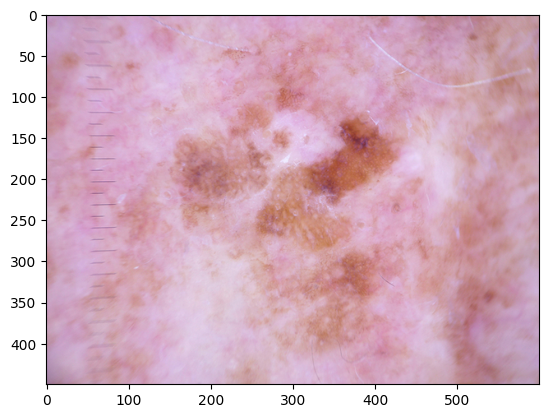

In [94]:
img = cv.imread(metadata.head(1)["path"].values[0])
print(f"image shape: {img.shape}")
plt.imshow(img[:, :, ::-1])

In [95]:
metadata.isna().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dataset         0
cell_type       0
cell_type_ix    0
path            0
dtype: int64

In [96]:
eda_condition = metadata.duplicated(subset="lesion_id")

In [97]:
eda_df = metadata.loc[~eda_condition]
eda_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002741...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002676...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_2\ISIC_003163...
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002917...
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002583...
...,...,...,...,...,...,...,...,...,...,...,...
9994,HAM_0000193,ISIC_0030877,akiec,histo,60.0,female,face,rosendahl,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003087...
10001,HAM_0000020,ISIC_0031922,akiec,histo,60.0,female,face,rosendahl,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003192...
10004,HAM_0005579,ISIC_0029309,akiec,histo,80.0,male,face,rosendahl,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_002930...
10008,HAM_0001576,ISIC_0033705,akiec,histo,60.0,male,face,vidir_modern,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003370...


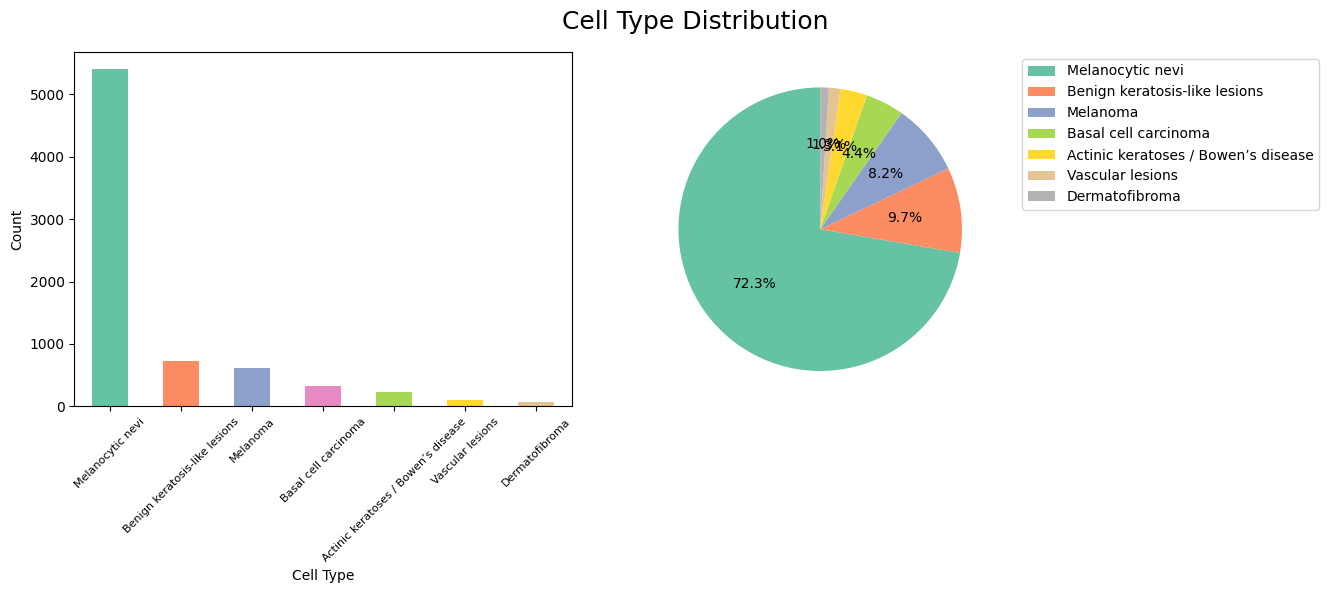

In [98]:
cell_counts = eda_df["cell_type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = sns.color_palette("Set2", len(cell_counts))

# Bar chart
cell_counts.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_xlabel("Cell Type")
axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=45
)
axes[0].tick_params(axis='x', labelsize=8)
axes[0].set_ylabel("Count")

# Pie chart
cell_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colormap="Set2",
    labels=None,
)

plt.legend(cell_counts.index, fontsize=10, bbox_to_anchor=(1.05, 1))
plt.suptitle("Cell Type Distribution", fontsize=18)
plt.ylabel("")
plt.tight_layout()
plt.show()

# Test Dataset Preprocessing

#### Initial data inspection

In [99]:
test_metadata = pd.read_csv('D:\skin\ISIC2018_Task3_Test_GroundTruth.csv')

In [100]:
test_metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     1512 non-null   str    
 1   image_id      1512 non-null   str    
 2   dx            1512 non-null   str    
 3   dx_type       1512 non-null   str    
 4   age           1230 non-null   float64
 5   sex           1511 non-null   str    
 6   localization  1511 non-null   str    
 7   dataset       1511 non-null   str    
dtypes: float64(1), str(7)
memory usage: 184.4 KB


#### Modifying the lesionID to matchh the training's form

In [101]:
test_metadata.head(1)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAMTEST_0000000,ISIC_0034524,nv,follow_up,40.0,female,back,vidir_molemax


In [102]:
metadata.head(1)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002741...


In [103]:
def modify_lesion_id(lesion_id):
    lesion_id = str(lesion_id)
    lesion_id = lesion_id.replace("TEST", "")
    return lesion_id

In [104]:
test_metadata["lesion_id"] = test_metadata["lesion_id"].apply(modify_lesion_id)

In [105]:
test_metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000000,ISIC_0034524,nv,follow_up,40.0,female,back,vidir_molemax
1,HAM_0000001,ISIC_0034525,nv,histo,70.0,male,abdomen,rosendahl
2,HAM_0000002,ISIC_0034526,bkl,histo,70.0,male,back,rosendahl
3,HAM_0000003,ISIC_0034527,nv,histo,35.0,male,trunk,vienna_dias
4,HAM_0000004,ISIC_0034528,nv,follow_up,75.0,female,trunk,vidir_molemax


#### Removing dupliacted rows and null values

In [106]:
test_metadata.isna().sum()

lesion_id         0
image_id          0
dx                0
dx_type           0
age             282
sex               1
localization      1
dataset           1
dtype: int64

In [107]:
test_metadata.duplicated().sum()

0

In [108]:
test_condition = test_metadata.duplicated(subset="lesion_id")
print(f"Number of duplicated unique id's: {test_condition.sum()}")

Number of duplicated unique id's: 289


In [109]:
test_metadata.loc[test_condition]

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
71,HAM_0000015,ISIC_0034596,bkl,histo,75.0,male,back,vidir_modern
131,HAM_0000059,ISIC_0034657,mel,histo,60.0,male,back,vidir_modern
144,HAM_0000091,ISIC_0034670,nv,histo,45.0,female,back,vidir_modern
158,HAM_0000023,ISIC_0034685,bkl,histo,90.0,male,back,rosendahl
172,HAM_0000164,ISIC_0034699,bcc,histo,70.0,male,back,rosendahl
...,...,...,...,...,...,...,...,...
1496,HAM_0001110,ISIC_0036049,nv,histo,40.0,male,back,vidir_modern
1498,HAM_0001055,ISIC_0036051,mel,histo,70.0,male,back,vidir_modern
1500,HAM_0001023,ISIC_0036053,bkl,histo,50.0,male,back,vidir_modern
1504,HAM_0001020,ISIC_0036057,mel,histo,25.0,female,upper extremity,vidir_modern


#### Encoding

In [110]:
print(f"unique diagnosis: {list(test_metadata['dx'].unique())}")

unique diagnosis: ['nv', 'bkl', 'mel', 'akiec', 'bcc', 'vasc', 'df']


In [111]:
dx_map = {
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratoses / Bowen’s disease",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "vasc": "Vascular lesions"
}


test_metadata["cell_type"] = test_metadata["dx"].map(dx_map.get)

In [112]:
test_metadata["cell_type_ix"] = pd.Categorical(test_metadata["cell_type"]).codes

In [113]:
test_metadata.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix
824,HAM_0000731,ISIC_0035369,nv,follow_up,50.0,female,trunk,vidir_molemax,Melanocytic nevi,4
1219,HAM_0001017,ISIC_0035772,bcc,histo,70.0,female,back,vidir_modern,Basal cell carcinoma,1
662,HAM_0000606,ISIC_0035201,nv,follow_up,55.0,female,lower extremity,vidir_molemax,Melanocytic nevi,4
137,HAM_0000135,ISIC_0034663,bkl,histo,NaN,unknown,unknown,external,Benign keratosis-like lesions,2
899,HAM_0000434,ISIC_0035447,nv,histo,5.0,female,face,vidir_modern,Melanocytic nevi,4



##### dx_type (diagnosis confirmation)
- `histo` : Histopathology  
- `follow_up` : Follow-up examination  
- `consensus` : Expert consensus  
- `confocal` : Confocal microscopy

In [114]:
print(f"unique diagnosis confirmation: {list(test_metadata["dx_type"].unique())}")

unique diagnosis confirmation: ['follow_up', 'histo', 'consensus', 'confocal']


In [115]:
print(f"unique localizations: {list(test_metadata["localization"].unique())}")

unique localizations: ['back', 'abdomen', 'trunk', 'unknown', 'lower extremity', 'upper extremity', 'face', 'chest', 'hand', 'foot', 'neck', 'ear', 'scalp', 'genital', nan]


##### Meaning of Each Source

- **rosendahl**  
  Images contributed from the Rosendahl collection / clinic source.

- **vienna_dias**  
  Images from a Vienna dermatology source (often one of the Austrian contributors).

- **vidir_molemax**  
  Images captured using MoleMax system by VIDIR.

- **vidir_modern**  
  Images from newer / modern VIDIR acquisition devices.

In [116]:
print(f"unique datasets: {list(test_metadata["dataset"].unique())}")

unique datasets: ['vidir_molemax', 'rosendahl', 'vienna_dias', 'external', 'vidir_modern', nan]


#### Adding images paths

In [117]:
test_data_dir = '../ISIC2018_Task3_Test_Images'
all_test_images_path = glob(os.path.join(test_data_dir, '*', '*.jpg'))
test_imageid_dict = { os.path.splitext( os.path.basename(x))[0]: x for x in all_test_images_path }

In [118]:
test_metadata["path"] = test_metadata["image_id"].map(test_imageid_dict.get)

In [119]:
test_metadata.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path
89,HAM_0000088,ISIC_0034614,bkl,consensus,70.0,female,neck,vidir_molemax,Benign keratosis-like lesions,2,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...
413,HAM_0000390,ISIC_0034944,nv,histo,65.0,male,upper extremity,rosendahl,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...
1026,HAM_0000883,ISIC_0035577,nv,follow_up,50.0,male,abdomen,vidir_molemax,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...
1081,HAM_0000432,ISIC_0035634,bkl,histo,50.0,male,trunk,vidir_modern,Benign keratosis-like lesions,2,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...
939,HAM_0000815,ISIC_0035487,bkl,histo,65.0,male,chest,rosendahl,Benign keratosis-like lesions,2,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...


image shape: (450, 600, 3)


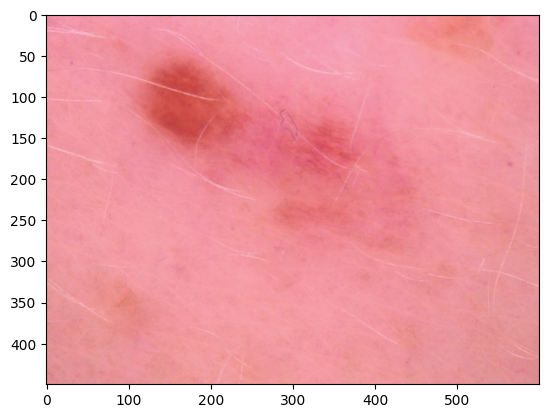

In [120]:
img = cv.imread(test_metadata.head(1)["path"].values[0])
print(f"image shape: {img.shape}")
plt.imshow(img[:, :, ::-1])

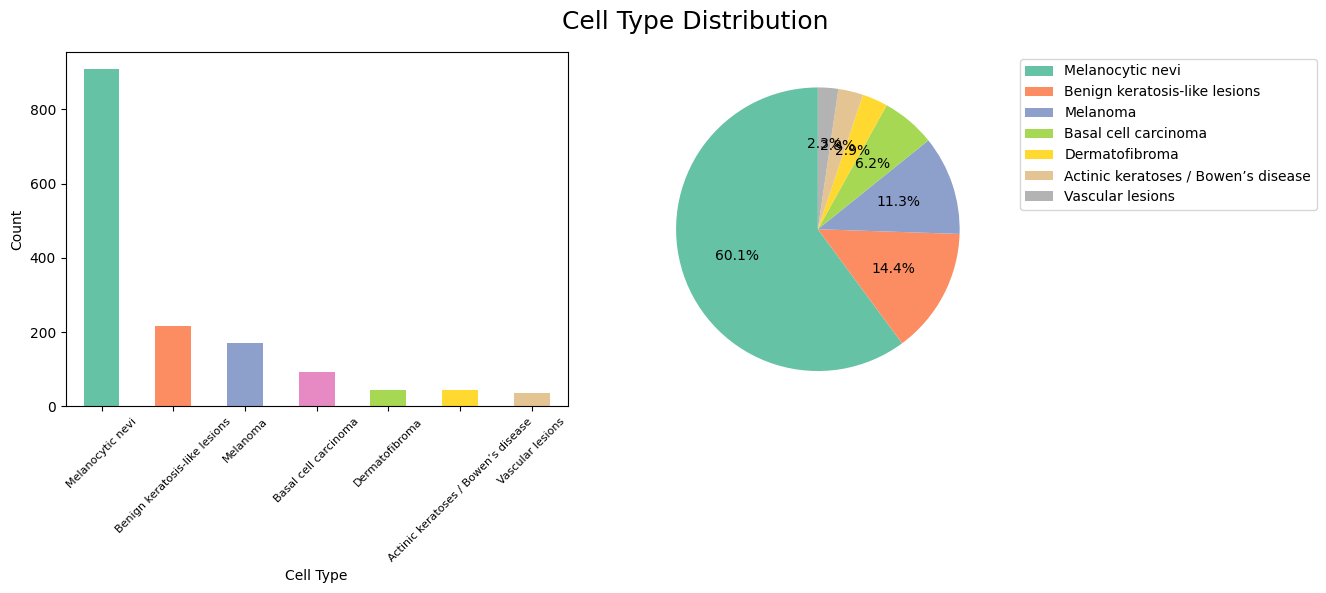

In [121]:
cell_counts = test_metadata["cell_type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = sns.color_palette("Set2", len(cell_counts))

# Bar chart
cell_counts.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_xlabel("Cell Type")
axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=45
)
axes[0].tick_params(axis='x', labelsize=8)
axes[0].set_ylabel("Count")

# Pie chart
cell_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colormap="Set2",
    labels=None,
)

plt.legend(cell_counts.index, fontsize=10, bbox_to_anchor=(1.05, 1))
plt.suptitle("Cell Type Distribution", fontsize=18)
plt.ylabel("")
plt.tight_layout()
plt.show()

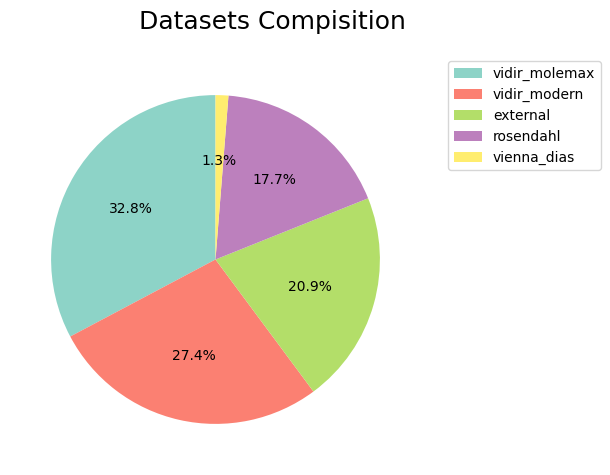

In [122]:
datasets_counts = test_metadata["dataset"].value_counts()


# Pie chart
datasets_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colormap="Set3",
    labels=None,   # remove clutter
)

plt.legend(datasets_counts.index, fontsize=10, bbox_to_anchor=(1.05, 1))
plt.suptitle("Datasets Compisition", fontsize=18)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [123]:
test_eda_condition = test_metadata.duplicated(subset="lesion_id", keep=False)

test_metadata.loc[test_eda_condition, "duplicated" ] = "YES"
test_metadata.loc[~test_eda_condition, "duplicated" ] = "NO"

In [124]:
test_metadata["duplicated"].value_counts()

duplicated
NO     997
YES    515
Name: count, dtype: int64

Text(0.5, 0, 'Duplicated Lesion ID')

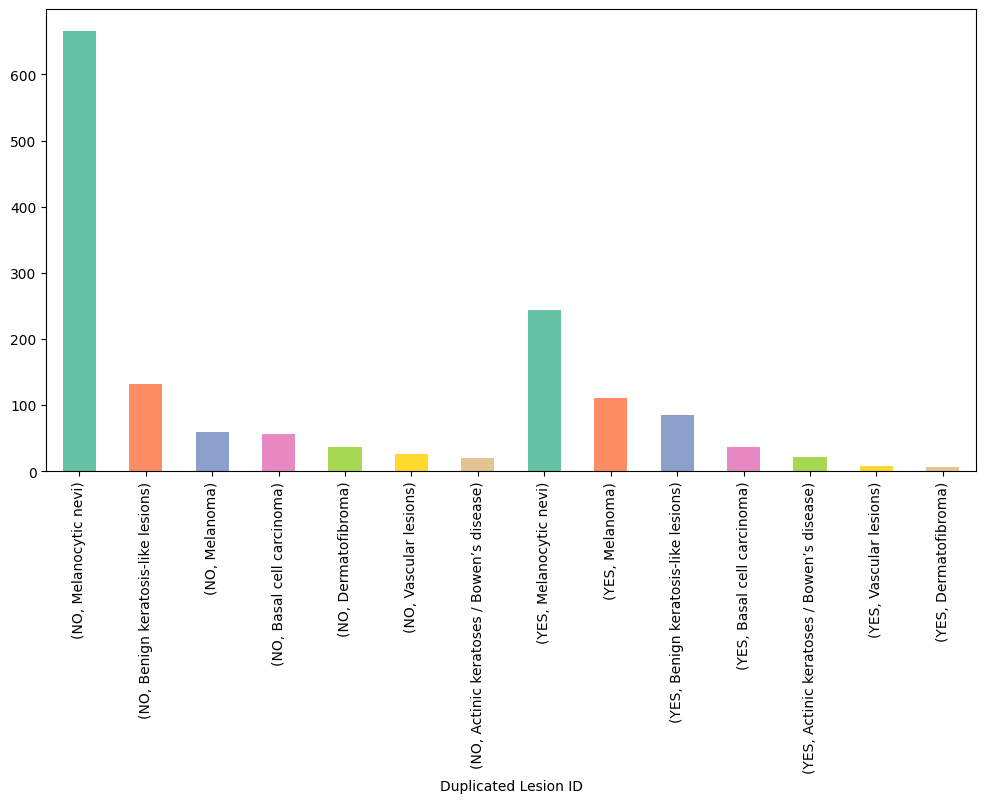

In [125]:
test_metadata.groupby("duplicated")["cell_type"].value_counts().plot(kind="bar", figsize=(12, 6), color=sns.color_palette("Set2", len(cell_counts)))
plt.xlabel("Duplicated Lesion ID")

#### Checking if the lessions in the testing dataset exist in the training dataset or not?

In [126]:
unique_training_lesions = set(metadata["lesion_id"].unique())
unique_test_lesions = set(test_metadata["lesion_id"].unique())

In [127]:
print(unique_test_lesions.intersection(unique_training_lesions))

{'HAM_0000334', 'HAM_0000097', 'HAM_0000642', 'HAM_0000087', 'HAM_0000816', 'HAM_0000691', 'HAM_0000351', 'HAM_0000047', 'HAM_0000414', 'HAM_0000661', 'HAM_0000294', 'HAM_0001158', 'HAM_0000175', 'HAM_0001180', 'HAM_0001177', 'HAM_0000319', 'HAM_0001089', 'HAM_0000547', 'HAM_0001045', 'HAM_0001201', 'HAM_0000104', 'HAM_0000881', 'HAM_0000773', 'HAM_0000895', 'HAM_0001007', 'HAM_0000320', 'HAM_0000604', 'HAM_0000869', 'HAM_0000384', 'HAM_0000737', 'HAM_0001020', 'HAM_0000637', 'HAM_0000805', 'HAM_0000015', 'HAM_0000149', 'HAM_0000313', 'HAM_0000204', 'HAM_0000361', 'HAM_0000607', 'HAM_0000391', 'HAM_0000404', 'HAM_0000108', 'HAM_0000159', 'HAM_0000823', 'HAM_0000437', 'HAM_0000575', 'HAM_0000195', 'HAM_0000672', 'HAM_0000500', 'HAM_0000682', 'HAM_0000778', 'HAM_0000942', 'HAM_0001030', 'HAM_0000178', 'HAM_0000738', 'HAM_0000202', 'HAM_0000024', 'HAM_0000122', 'HAM_0000935', 'HAM_0001116', 'HAM_0000448', 'HAM_0000021', 'HAM_0000077', 'HAM_0000731', 'HAM_0000748', 'HAM_0000522', 'HAM_0000

In [128]:
test_metadata.loc[test_metadata["lesion_id"].isin(unique_training_lesions)]

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path,duplicated
0,HAM_0000000,ISIC_0034524,nv,follow_up,40.0,female,back,vidir_molemax,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
1,HAM_0000001,ISIC_0034525,nv,histo,70.0,male,abdomen,rosendahl,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,YES
2,HAM_0000002,ISIC_0034526,bkl,histo,70.0,male,back,rosendahl,Benign keratosis-like lesions,2,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
3,HAM_0000003,ISIC_0034527,nv,histo,35.0,male,trunk,vienna_dias,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
4,HAM_0000004,ISIC_0034528,nv,follow_up,75.0,female,trunk,vidir_molemax,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
...,...,...,...,...,...,...,...,...,...,...,...,...
1507,HAM_0001219,ISIC_0036060,bkl,consensus,NaN,unknown,unknown,external,Benign keratosis-like lesions,2,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
1508,HAM_0001220,ISIC_0036061,nv,consensus,NaN,unknown,unknown,external,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
1509,HAM_0001107,ISIC_0036062,akiec,histo,70.0,female,face,vidir_modern,Actinic keratoses / Bowen’s disease,0,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,YES
1510,HAM_0001221,ISIC_0036063,bkl,consensus,NaN,unknown,unknown,external,Benign keratosis-like lesions,2,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO


In [129]:
metadata.loc[metadata['lesion_id'] == 'HAM_0000004']

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path
4918,HAM_0000004,ISIC_0024645,nv,follow_up,40.0,female,back,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_1\ISIC_002464...


In [130]:
unique_training_imageIDs = set(metadata["image_id"].unique())
unique_test_imageIDs = set(test_metadata["image_id"].unique())

In [131]:
print(set(unique_test_imageIDs.intersection(unique_training_imageIDs)))

set()


In [132]:
test_metadata.isna().sum() 

lesion_id         0
image_id          0
dx                0
dx_type           0
age             282
sex               1
localization      1
dataset           1
cell_type         0
cell_type_ix      0
path              1
duplicated        0
dtype: int64

In [133]:
test_metadata.loc[ test_metadata["path"].isna() ]

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path,duplicated
534,HAM_0000496,ISIC_0035068,nv,consensus,NaN,NaN,NaN,NaN,Melanocytic nevi,4,NaN,NO


In [134]:
test_metadata.dropna(subset=["path"], inplace=True)

In [135]:
test_metadata.loc[ test_metadata["path"].isna() ]

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path,duplicated


In [136]:
test_metadata.reset_index(drop=True, inplace=True)

In [137]:
test_metadata

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path,duplicated
0,HAM_0000000,ISIC_0034524,nv,follow_up,40.0,female,back,vidir_molemax,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
1,HAM_0000001,ISIC_0034525,nv,histo,70.0,male,abdomen,rosendahl,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,YES
2,HAM_0000002,ISIC_0034526,bkl,histo,70.0,male,back,rosendahl,Benign keratosis-like lesions,2,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
3,HAM_0000003,ISIC_0034527,nv,histo,35.0,male,trunk,vienna_dias,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
4,HAM_0000004,ISIC_0034528,nv,follow_up,75.0,female,trunk,vidir_molemax,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
...,...,...,...,...,...,...,...,...,...,...,...,...
1506,HAM_0001219,ISIC_0036060,bkl,consensus,NaN,unknown,unknown,external,Benign keratosis-like lesions,2,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
1507,HAM_0001220,ISIC_0036061,nv,consensus,NaN,unknown,unknown,external,Melanocytic nevi,4,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO
1508,HAM_0001107,ISIC_0036062,akiec,histo,70.0,female,face,vidir_modern,Actinic keratoses / Bowen’s disease,0,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,YES
1509,HAM_0001221,ISIC_0036063,bkl,consensus,NaN,unknown,unknown,external,Benign keratosis-like lesions,2,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...,NO


# 2 Data splitting 

In [138]:
condition = metadata.duplicated(subset="lesion_id", keep=False)

metadata.loc[condition, "duplicated" ] = "YES"
metadata.loc[~condition, "duplicated" ] = "NO"

In [139]:
metadata["duplicated"].value_counts()

duplicated
NO     5514
YES    4501
Name: count, dtype: int64

Text(0.5, 0, 'Duplicated Lesion ID')

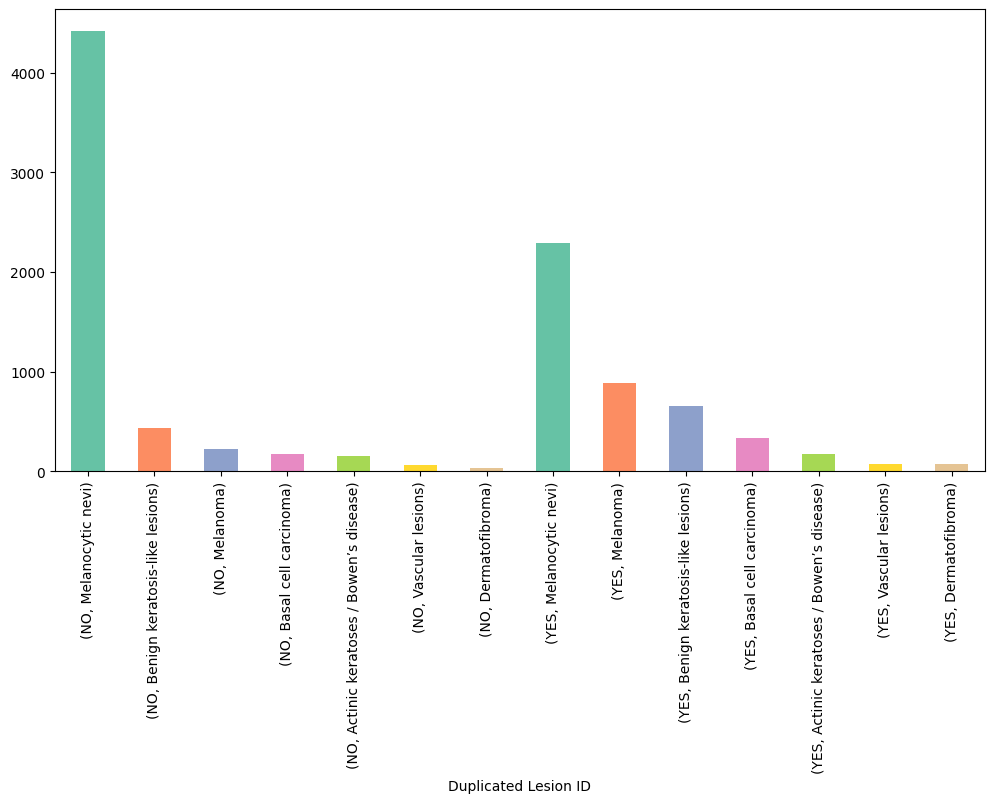

In [140]:
metadata.groupby("duplicated")["cell_type"].value_counts().plot(kind="bar", figsize=(12, 6), color=sns.color_palette("Set2", len(cell_counts)))
plt.xlabel("Duplicated Lesion ID")

In [141]:
unduplicated = metadata.loc[metadata["duplicated"] == "NO"]
duplicated = metadata.loc[metadata["duplicated"] == "YES"]

unduplicated.reset_index(inplace=True, drop=True)
duplicated.reset_index(inplace=True, drop=True)

In [142]:
print(unduplicated.shape)
print(duplicated.shape)

(5514, 12)
(4501, 12)


Removing the most reprensted class in the duplicated dataset, while removing only the duplication but keeping 1 image per lession

In [143]:
duplicated["dx"].value_counts()

dx
nv       2290
mel       883
bkl       659
bcc       339
akiec     176
vasc       78
df         76
Name: count, dtype: int64

In [144]:
duplicated_nv_lesions = duplicated[
    (duplicated["dx"] == "nv") &
    (duplicated.duplicated(subset="lesion_id"))
]

print(duplicated_nv_lesions["dx"].unique())
print(duplicated_nv_lesions.shape)

<ArrowStringArray>
['nv']
Length: 1, dtype: str
(1302, 12)


In [145]:
duplicated = duplicated[~duplicated.index.isin(duplicated_nv_lesions.index)]

In [146]:
duplicated["dx"].value_counts()

dx
nv       988
mel      883
bkl      659
bcc      339
akiec    176
vasc      78
df        76
Name: count, dtype: int64

In [147]:
from sklearn.model_selection import train_test_split

In [149]:
y = unduplicated["cell_type_ix"]

df_rest, df_val = train_test_split(
    unduplicated,
    test_size=0.15,
    random_state=42,
    stratify=y #preserves same class balance of the original df sould consider removing it i balance the data later
)

In [150]:
df_val.reset_index(drop=True)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path,duplicated
0,HAM_0006224,ISIC_0029351,nv,follow_up,55.0,male,abdomen,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_002935...,NO
1,HAM_0002943,ISIC_0026054,nv,follow_up,50.0,male,lower extremity,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_1\ISIC_002605...,NO
2,HAM_0007121,ISIC_0029922,nv,follow_up,35.0,male,back,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_002992...,NO
3,HAM_0007137,ISIC_0031327,nv,follow_up,65.0,male,abdomen,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_003132...,NO
4,HAM_0007536,ISIC_0025445,nv,follow_up,55.0,female,abdomen,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_1\ISIC_002544...,NO
...,...,...,...,...,...,...,...,...,...,...,...,...
823,HAM_0002113,ISIC_0029839,mel,histo,65.0,male,back,rosendahl,Melanoma,5,../training\HAM10000_images_part_2\ISIC_002983...,NO
824,HAM_0000461,ISIC_0027750,nv,follow_up,30.0,female,abdomen,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_1\ISIC_002775...,NO
825,HAM_0000141,ISIC_0030477,nv,follow_up,35.0,female,lower extremity,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_003047...,NO
826,HAM_0001166,ISIC_0026851,nv,follow_up,45.0,female,trunk,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_1\ISIC_002685...,NO


In [151]:
print(f"y shape: {y.shape}")
print(f"rest shape: {df_rest.shape}")
print(f"df_val shape: {df_val.shape}")

y shape: (5514,)
rest shape: (4686, 12)
df_val shape: (828, 12)


In [152]:
df_train = pd.concat([df_rest, duplicated]).reset_index(drop=True)

In [153]:
df_train

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path,duplicated
0,HAM_0003481,ISIC_0029050,nv,follow_up,35.0,female,back,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_1\ISIC_002905...,NO
1,HAM_0001806,ISIC_0026920,nv,follow_up,50.0,female,abdomen,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_1\ISIC_002692...,NO
2,HAM_0004006,ISIC_0031653,nv,follow_up,55.0,male,lower extremity,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_003165...,NO
3,HAM_0000561,ISIC_0025143,nv,follow_up,45.0,male,genital,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_1\ISIC_002514...,NO
4,HAM_0001023,ISIC_0026468,akiec,histo,50.0,male,hand,rosendahl,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_1\ISIC_002646...,NO
...,...,...,...,...,...,...,...,...,...,...,...,...
7880,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,vidir_modern,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003308...,YES
7881,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,vidir_modern,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003355...,YES
7882,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,vidir_modern,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003353...,YES
7883,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,vidir_modern,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003285...,YES


In [154]:
df_train["cell_type_ix"].value_counts()/df_train.shape[0]

cell_type_ix
4    0.601141
5    0.136842
2    0.131008
1    0.061890
0    0.038554
6    0.016741
3    0.013824
Name: count, dtype: float64

In [155]:
df_val["cell_type_ix"].value_counts()/df_val.shape[0]

cell_type_ix
4    0.800725
2    0.079710
5    0.041063
1    0.031401
0    0.027778
6    0.012077
3    0.007246
Name: count, dtype: float64

In [156]:
test_metadata["cell_type_ix"].value_counts()/test_metadata.shape[0]

cell_type_ix
4    0.600927
2    0.143614
5    0.113170
1    0.061549
3    0.029120
0    0.028458
6    0.023163
Name: count, dtype: float64

Text(0.5, 0, 'Duplicated Lesion ID')

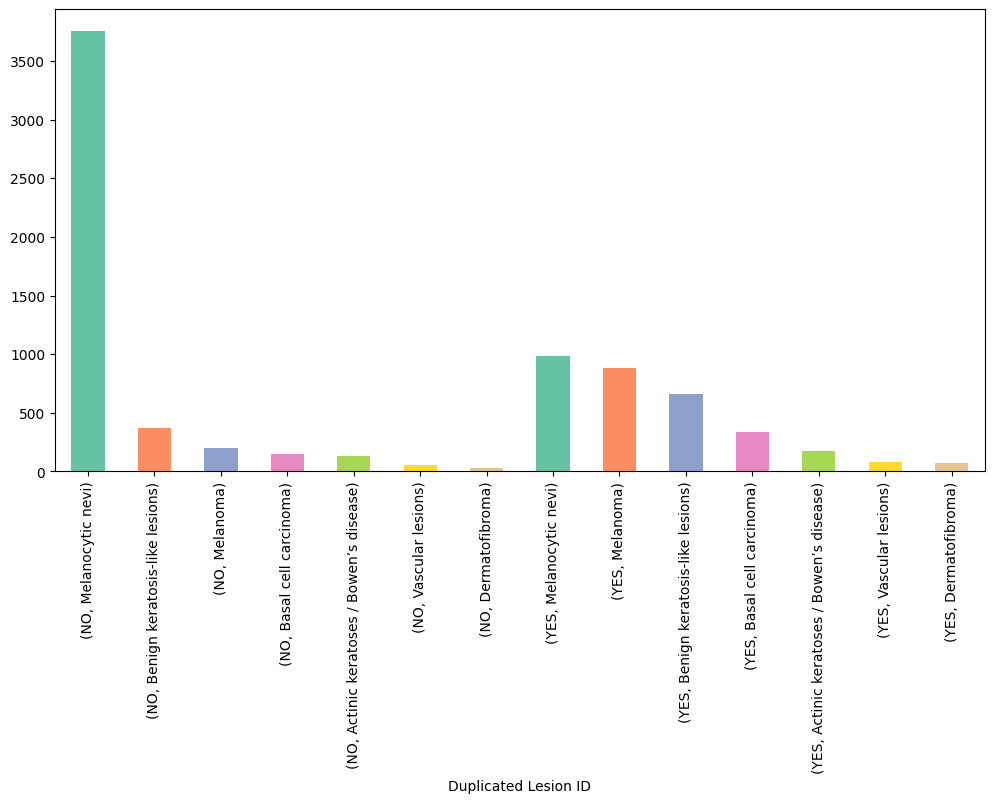

In [157]:
df_train.groupby("duplicated")["cell_type"].value_counts().plot(kind="bar", figsize=(12, 6), color=sns.color_palette("Set2", len(cell_counts)))
plt.xlabel("Duplicated Lesion ID")

Text(0.5, 0, 'Duplicated Lesion ID')

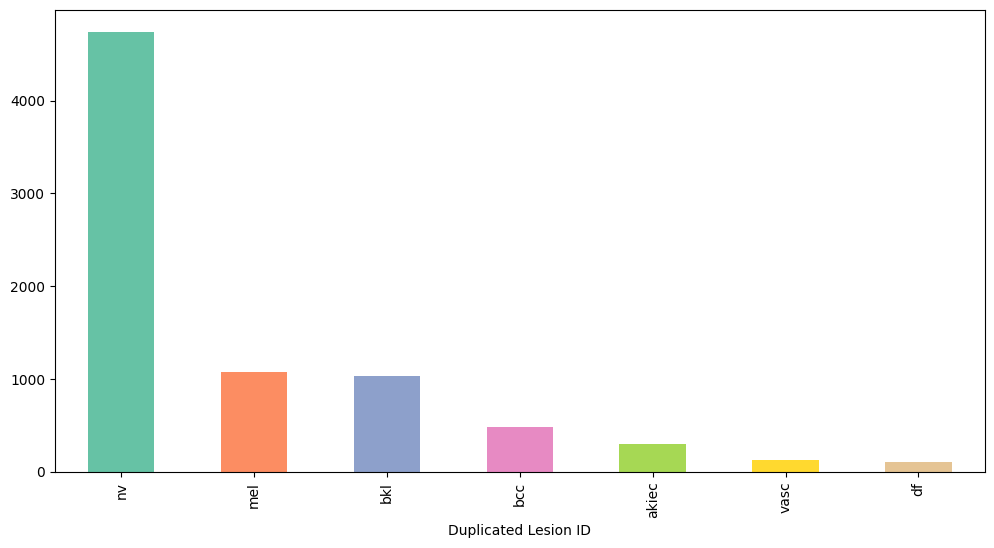

In [158]:
df_train["dx"].value_counts().plot(kind="bar", figsize=(12, 6), color=sns.color_palette("Set2", len(cell_counts)))
plt.xlabel("Duplicated Lesion ID")

# 3. Data augumentation 

removing the nv class from duplicted class and try to generate new images for lower classes wiht no duplicated to balance the data

In [159]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

In [160]:
y_train = df_train["cell_type_ix"]

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{0: 3.705357142857143, 1: 2.308255269320843, 2: 1.0904439220024893, 3: 10.334207077326344, 4: 0.23764315852923448, 5: 1.043956043956044, 6: 8.533549783549784}


In [161]:
strong_gen = ImageDataGenerator(

    rotation_range=60,

    zoom_range=0.30,

    width_shift_range=0.15,
    height_shift_range=0.15,

    shear_range=0.15,

    horizontal_flip=True,
    vertical_flip=True,

    brightness_range=[0.7, 1.3],

    channel_shift_range=25.0,

    fill_mode="reflect"
)



medium_gen = ImageDataGenerator(

    rotation_range=35,

    zoom_range=0.20,

    width_shift_range=0.10,
    height_shift_range=0.10,

    shear_range=0.10,

    horizontal_flip=True,
    vertical_flip=True,

    brightness_range=[0.85, 1.15],

    fill_mode="nearest"
)


weak_gen = ImageDataGenerator(
    horizontal_flip=True,
)

In [162]:
df_train["dx"].value_counts()

dx
nv       4740
mel      1079
bkl      1033
bcc       488
akiec     304
vasc      132
df        109
Name: count, dtype: int64

In [163]:
augmentation_policy = {
    "nv": {
        "augment": False,
        "generator": weak_gen
    },
    "mel": {
        "augment": True,
        "generator": strong_gen
    },
    "bkl": {
        "augment": True,
        "generator": medium_gen
    },
    "bcc": {
        "augment": True,
        "generator": strong_gen
    },
    "akiec": {
        "augment": True,
        "generator": strong_gen
    },
    "vasc": {
        "augment": True,
        "generator": medium_gen
    },
    "df": {
        "augment": True,
        "generator": medium_gen
    }
}

In [164]:
metadata

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path,duplicated
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002741...,YES
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002503...,YES
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002676...,YES
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002566...,YES
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_2\ISIC_003163...,YES
...,...,...,...,...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,vidir_modern,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003308...,YES
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,vidir_modern,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003355...,YES
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,vidir_modern,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003353...,YES
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,vidir_modern,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003285...,YES


In [173]:
from tensorflow.keras.utils import Sequence


class SkinGenerator(Sequence):

    def __init__(self, df, batch_size=32, img_size=(150, 200)):

        self.df = df
        self.batch_size = batch_size
        self.img_size = img_size

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def on_epoch_end(self):
        self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, idx):

        batch = self.df.iloc[idx * self.batch_size : (idx + 1) * self.batch_size]

        images = []
        labels = []

        for _, row in batch.iterrows():

            image = cv.imread(row["path"])
            image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

            # RESIZE
            image = cv.resize(
                image,
                (self.img_size[1], self.img_size[0])
            )

            # ENCODED LABEL
            label = row["cell_type_ix"]


            policy = augmentation_policy[row["dx"]]

            if (
                policy["augment"] and
                row["duplicated"] == "NO"
            ):
                image = policy["generator"].random_transform(image)

            image = image.astype("float32") / 255.0

            images.append(image)
            labels.append(label)

        return (
            np.array(images, dtype=np.float32),
            np.array(labels, dtype=np.int32)
        )

# 4. Model Building

In [170]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

IMG_SHAPE = (150, 200, 3)
NUM_CLASSES = 7

In [167]:
def build_transfer_model(base_model_fn, name: str):
    base = base_model_fn(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SHAPE
    )

    base.trainable = False

    inputs = tf.keras.Input(shape=IMG_SHAPE)
    x = base(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs, outputs, name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [168]:
models_config = {
    "MobileNetV2": tf.keras.applications.MobileNetV2,
    "EfficientNetB0": tf.keras.applications.EfficientNetB0,
    "ResNet50": tf.keras.applications.ResNet50,
    "DenseNet121": tf.keras.applications.DenseNet121,
}

In [171]:
def evaluate_from_df(model, df, img_size=(150, 200)):
    y_true = []
    y_pred = []

    for _, row in df.iterrows():
        img = cv.imread(row["path"])
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        img = cv.resize(img, (img_size[1], img_size[0]))
        img = img.astype("float32") / 255.0

        pred = model.predict(np.expand_dims(img, axis=0), verbose=0)

        y_true.append(row["cell_type_ix"])
        y_pred.append(np.argmax(pred))

    return np.array(y_true), np.array(y_pred)

In [174]:
histories = {}
results = []
EPOCHS = 20

for name, base_fn in models_config.items():
    print(f"\n==================== {name} ====================\n")

    model = build_transfer_model(base_fn, name)

    history = model.fit(
        SkinGenerator(df_train),
        validation_data=SkinGenerator(df_val),
        epochs=EPOCHS,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=2
            )
        ]
    )

    y_true, y_pred = evaluate_from_df(model, test_metadata)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    histories[name] = history

    results.append((name, acc, f1))


==================== MobileNetV2 ====================

Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 221s 829ms/step - accuracy: 0.4583 - loss: 1.8473 - val_accuracy: 0.8043 - val_loss: 0.7475 - learning_rate: 1.0000e-04
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.6043 - loss: 1.3486 - val_accuracy: 0.8527 - val_loss: 0.5820 - learning_rate: 1.0000e-04
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.6563 - loss: 1.1378 - val_accuracy: 0.8756 - val_loss: 0.5527 - learning_rate: 1.0000e-04
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.6838 - loss: 1.0194 - val_accuracy: 0.8829 - val_loss: 0.4563 - learning_rate: 1.0000e-04
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.7065 - loss: 0.9295 - val_accuracy: 0.8527 - val_loss: 0.5734 - learning_rate: 1.0000e-04
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 163s 658ms/step - accuracy: 0.7195 - loss: 0.8503 - val_accuracy: 0.8937 - val_loss: 0.4040 - learning_rate: 1.0000e

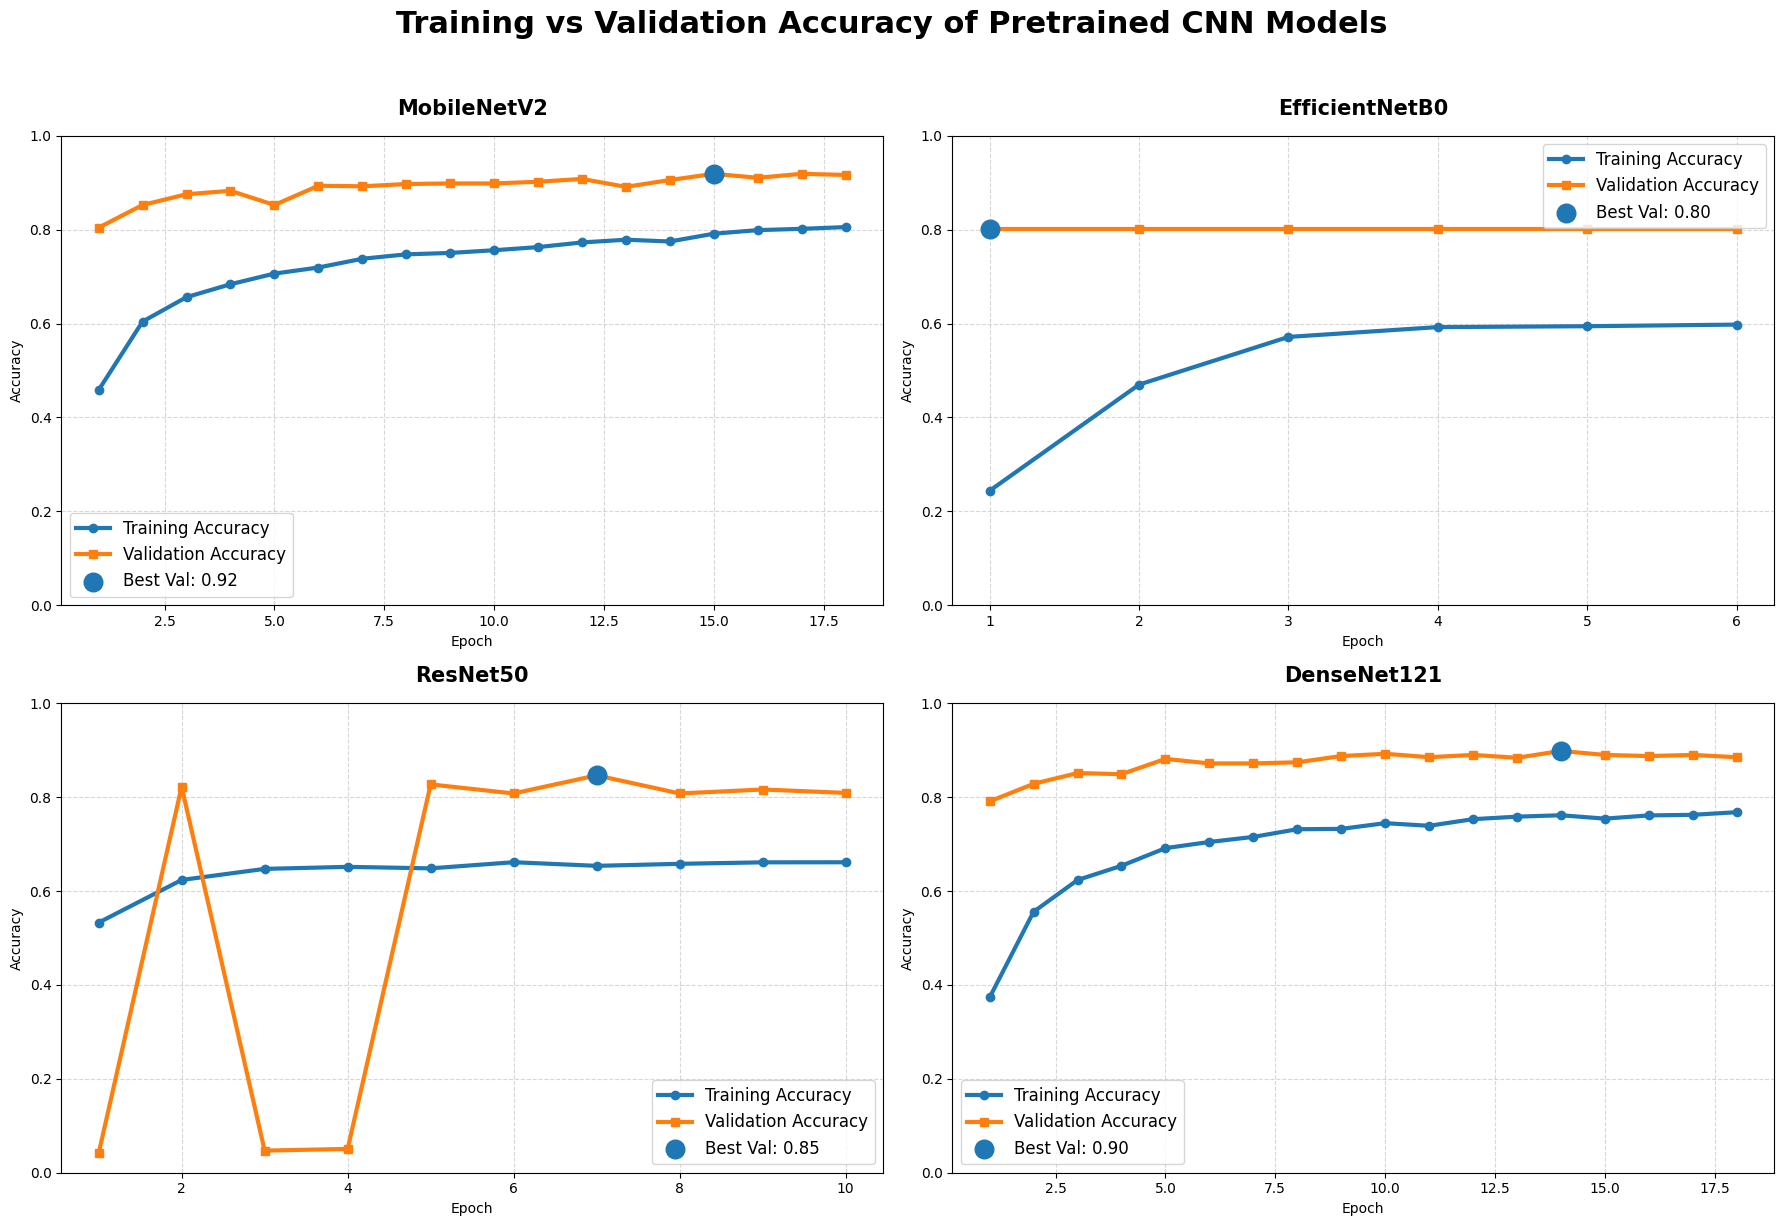

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes = axes.flatten()

# -----------------------------
# STYLE
# -----------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12
})

# -----------------------------
# LOOP THROUGH MODELS
# -----------------------------
for idx, (name, history) in enumerate(histories.items()):

    ax = axes[idx]

    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]

    epochs_range = range(1, len(train_acc) + 1)

    # TRAIN
    ax.plot(
        epochs_range,
        train_acc,
        linewidth=3,
        marker='o',
        markersize=6,
        label="Training Accuracy"
    )

    # VALIDATION
    ax.plot(
        epochs_range,
        val_acc,
        linewidth=3,
        marker='s',
        markersize=6,
        label="Validation Accuracy"
    )

    # BEST VAL POINT
    best_epoch = np.argmax(val_acc)
    best_acc = val_acc[best_epoch]

    ax.scatter(
        best_epoch + 1,
        best_acc,
        s=180,
        zorder=5,
        label=f"Best Val: {best_acc:.2f}"
    )

    # TITLES
    ax.set_title(f"{name}", pad=15, weight="bold")

    # AXIS LABELS
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")

    # GRID
    ax.grid(True, linestyle="--", alpha=0.5)

    # LIMITS
    ax.set_ylim(0, 1)

    # LEGEND
    ax.legend()

# -----------------------------
# MAIN TITLE
# -----------------------------
fig.suptitle(
    "Training vs Validation Accuracy of Pretrained CNN Models",
    fontsize=22,
    weight="bold",
    y=1.02
)

# -----------------------------
# LAYOUT
# -----------------------------
plt.tight_layout()

plt.show()

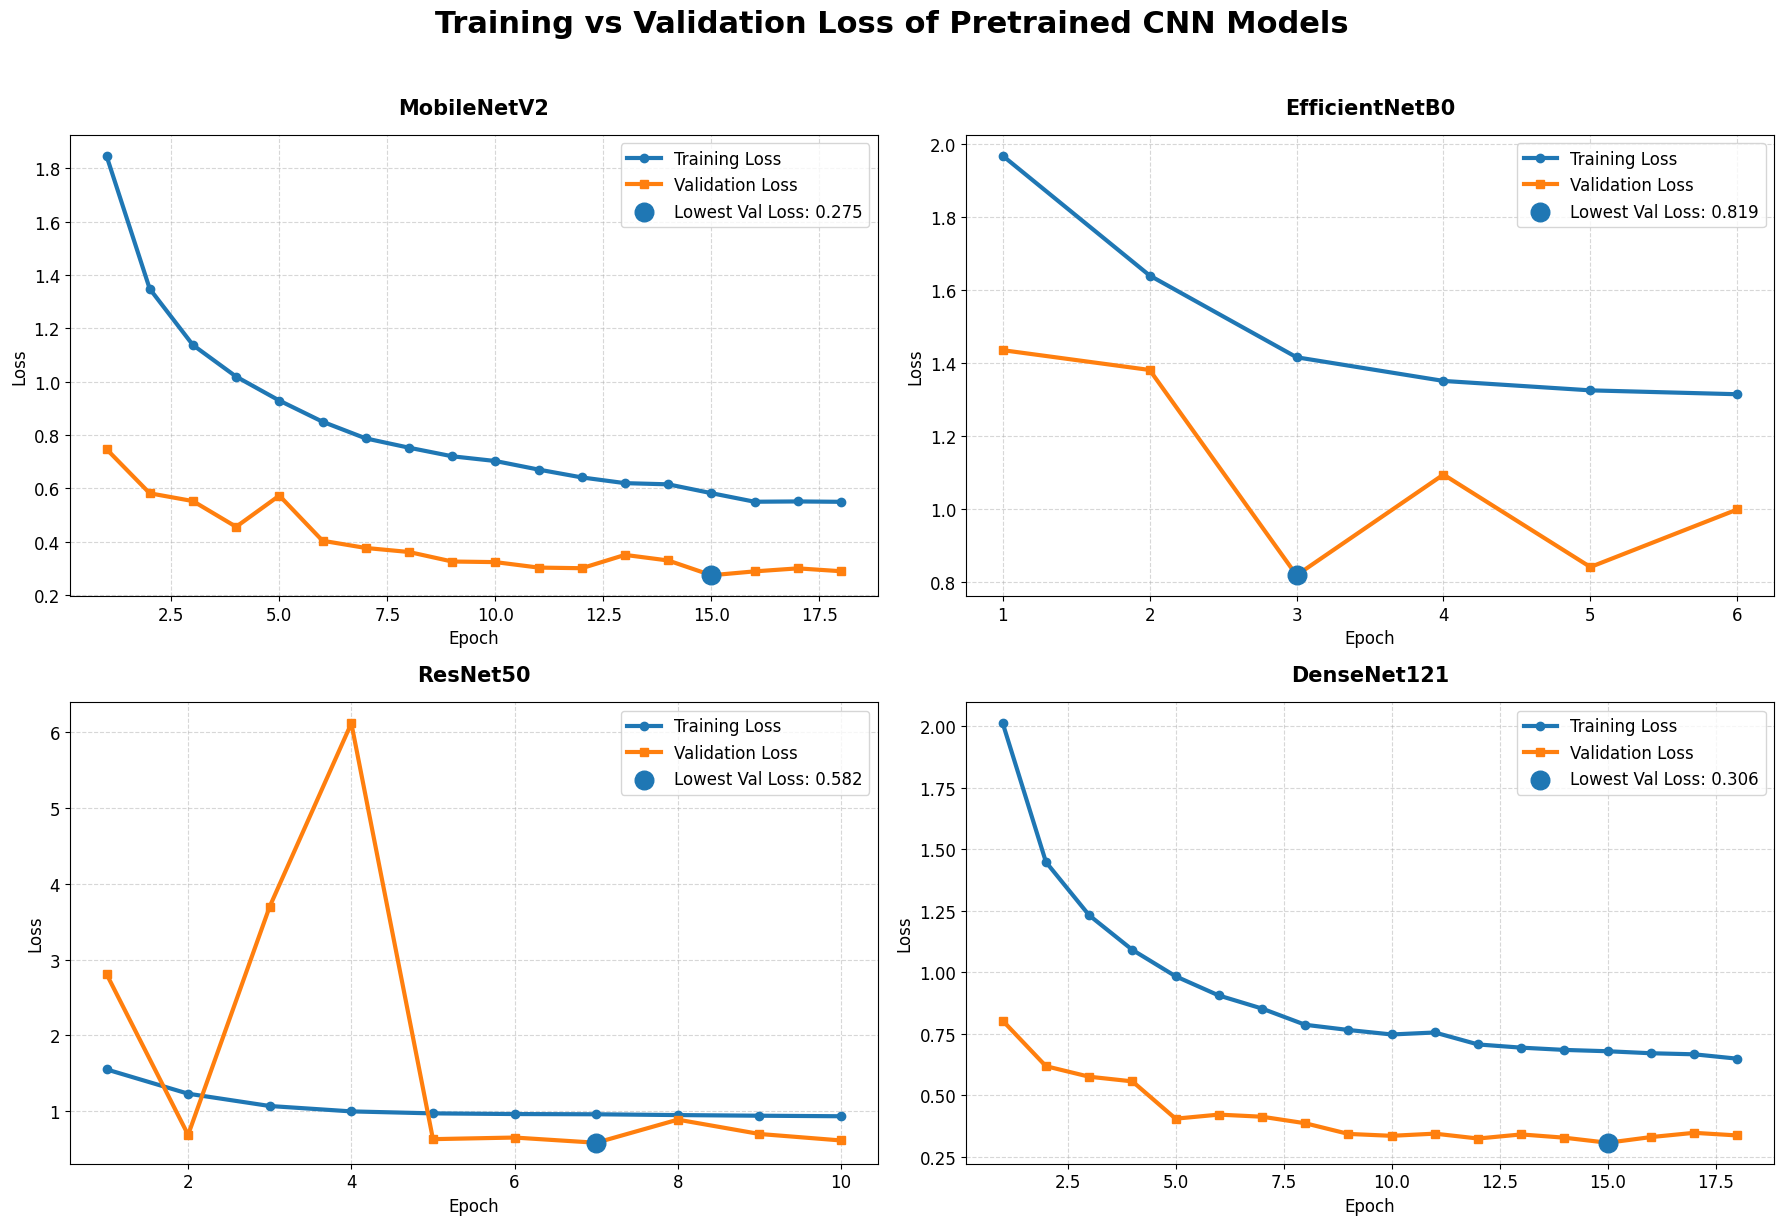

In [177]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes = axes.flatten()

# -----------------------------
# STYLE
# -----------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12
})

# -----------------------------
# LOOP THROUGH MODELS
# -----------------------------
for idx, (name, history) in enumerate(histories.items()):

    ax = axes[idx]

    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(train_loss) + 1)

    # TRAIN LOSS
    ax.plot(
        epochs_range,
        train_loss,
        linewidth=3,
        marker='o',
        markersize=6,
        label="Training Loss"
    )

    # VALIDATION LOSS
    ax.plot(
        epochs_range,
        val_loss,
        linewidth=3,
        marker='s',
        markersize=6,
        label="Validation Loss"
    )

    # BEST VAL LOSS POINT
    best_epoch = np.argmin(val_loss)
    best_loss = val_loss[best_epoch]

    ax.scatter(
        best_epoch + 1,
        best_loss,
        s=180,
        zorder=5,
        label=f"Lowest Val Loss: {best_loss:.3f}"
    )

    # TITLES
    ax.set_title(f"{name}", pad=15, weight="bold")

    # AXIS LABELS
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")

    # GRID
    ax.grid(True, linestyle="--", alpha=0.5)

    # LEGEND
    ax.legend()

# -----------------------------
# MAIN TITLE
# -----------------------------
fig.suptitle(
    "Training vs Validation Loss of Pretrained CNN Models",
    fontsize=22,
    weight="bold",
    y=1.02
)

# -----------------------------
# LAYOUT
# -----------------------------
plt.tight_layout()

plt.show()

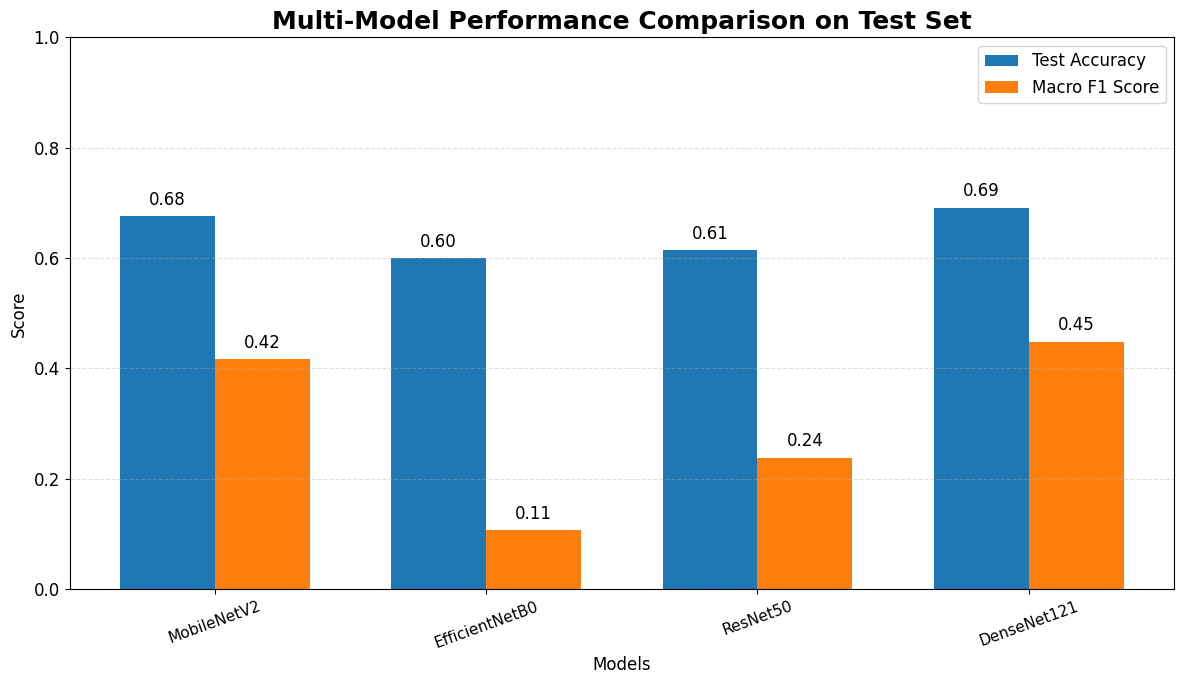

In [179]:
# -----------------------------
# EXTRACT DATA
# -----------------------------
model_names = [r[0] for r in results]
accuracies = [r[1] for r in results]
f1_scores = [r[2] for r in results]

x = np.arange(len(model_names))
width = 0.35

# -----------------------------
# FIGURE SETUP
# -----------------------------
plt.figure(figsize=(12, 7))

# -----------------------------
# BARS
# -----------------------------
plt.bar(x - width/2, accuracies, width, label="Test Accuracy")
plt.bar(x + width/2, f1_scores, width, label="Macro F1 Score")

# -----------------------------
# LABELS + STYLE
# -----------------------------
plt.xticks(x, model_names, rotation=20, fontsize=11)
plt.ylim(0, 1)

plt.ylabel("Score")
plt.xlabel("Models")

plt.title(
    "Multi-Model Performance Comparison on Test Set",
    fontsize=18,
    weight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

# -----------------------------
# VALUE LABELS ON TOP
# -----------------------------
for i in range(len(model_names)):
    plt.text(i - width/2, accuracies[i] + 0.02, f"{accuracies[i]:.2f}", ha='center')
    plt.text(i + width/2, f1_scores[i] + 0.02, f"{f1_scores[i]:.2f}", ha='center')

# -----------------------------
# SHOW
# -----------------------------
plt.tight_layout()
plt.show()

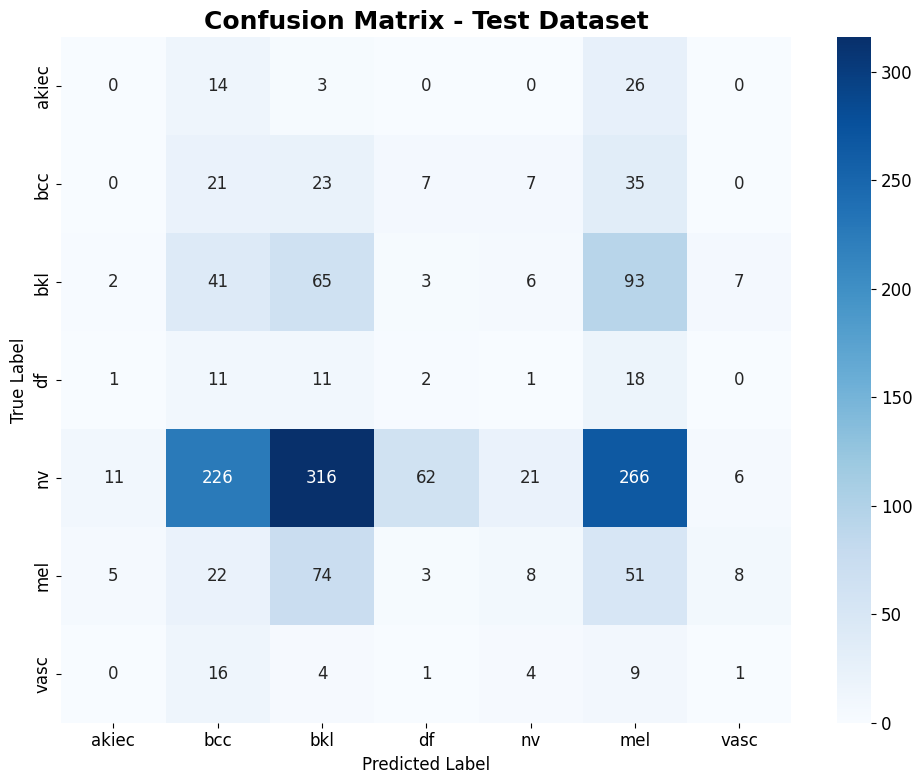

In [ ]:
from sklearn.metrics import confusion_matrix


# GET PREDICTIONS
y_true, y_pred = evaluate_from_df(model, test_metadata)

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

In [181]:
class_names = {
    0: "akiec",
    1: "bcc",
    2: "bkl",
    3: "df",
    4: "nv",
    5: "mel",
    6: "vasc"
}

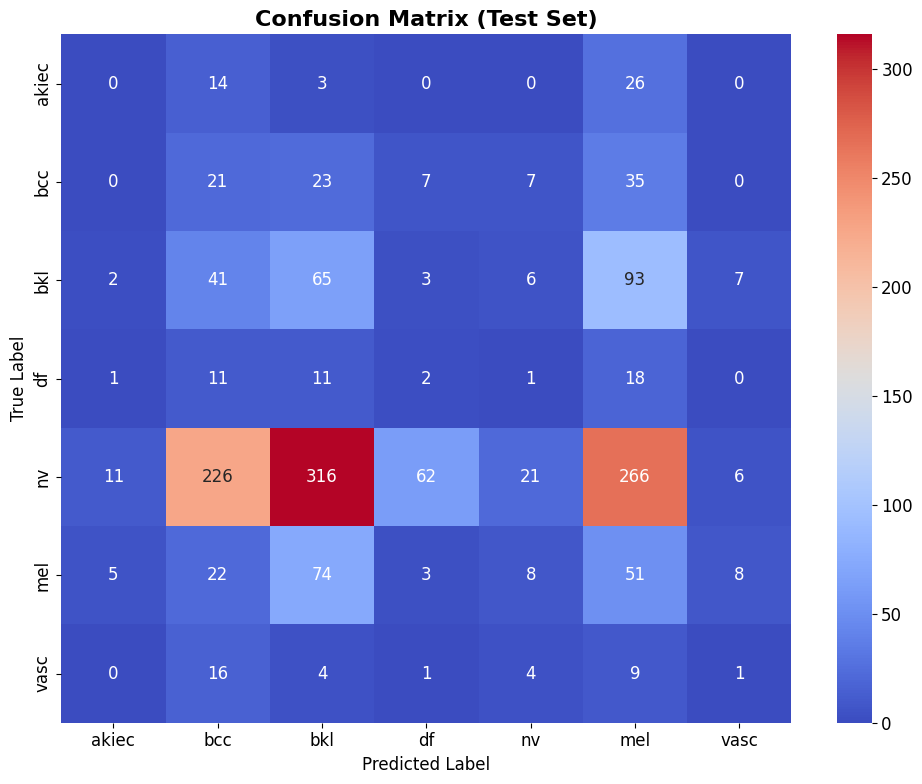

In [ ]:
class_names = [class_names[i] for i in sorted(class_names.keys())]

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix (Test Set)", fontsize=16, weight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

## Hypertuning

In [185]:
import tensorflow as tf


for layer in model.layers:
    print(layer.name)

input_layer_12
mobilenetv2_1.00_224
global_average_pooling2d_5
dense_10
batch_normalization_5
dropout_5
dense_11


In [186]:
for layer in model.layers:
    layer.trainable = True

In [187]:
for layer in model.layers:
    if layer.name == "mobilenetv2_1.00_224":
        layer.trainable = True
    else:
        layer.trainable = True

In [188]:
# find backbone layer
base_model = None

for layer in model.layers:
    if layer.name == "mobilenetv2_1.00_224":
        base_model = layer
        break

In [189]:
base_model.trainable = True

# freeze first part, fine-tune last part
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

In [190]:
for layer in model.layers:
    if layer.name != "mobilenetv2_1.00_224":
        layer.trainable = True

In [191]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [193]:
history_finetune = model.fit(
    SkinGenerator(df_train),
    validation_data=SkinGenerator(df_val),
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2
        )
    ]
)

Epoch 1/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 194s 714ms/step - accuracy: 0.3146 - loss: 2.3063 - val_accuracy: 0.5918 - val_loss: 1.2232 - learning_rate: 1.0000e-05
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 213s 860ms/step - accuracy: 0.4893 - loss: 1.8085 - val_accuracy: 0.7560 - val_loss: 0.7800 - learning_rate: 1.0000e-05
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 232s 938ms/step - accuracy: 0.5585 - loss: 1.5605 - val_accuracy: 0.8056 - val_loss: 0.6590 - learning_rate: 1.0000e-05
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 221s 892ms/step - accuracy: 0.6066 - loss: 1.3792 - val_accuracy: 0.8394 - val_loss: 0.5866 - learning_rate: 1.0000e-05
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 226s 914ms/step - accuracy: 0.6454 - loss: 1.2358 - val_accuracy: 0.8611 - val_loss: 0.5231 - learning_rate: 1.0000e-05
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 227s 919ms/step - accuracy: 0.6643 - loss: 1.1381 - val_accuracy: 0.8768 - val_loss: 0.4844 - learning_rate: 1.0000e-05
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 

In [194]:
def load_test_data(df, img_size=(150, 200)):
    images = []
    labels = []

    for _, row in df.iterrows():
        img = cv.imread(row["path"])
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        img = cv.resize(img, (img_size[1], img_size[0]))
        img = img.astype("float32") / 255.0

        images.append(img)
        labels.append(row["cell_type_ix"])

    return np.array(images), np.array(labels)


X_test, y_test = load_test_data(test_metadata)

In [195]:
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=1)

48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 473ms/step


In [196]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.17      0.26      0.21        43
           1       0.29      0.31      0.30        93
           2       0.45      0.25      0.32       217
           3       0.12      0.09      0.10        44
           4       0.79      0.90      0.84       908
           5       0.31      0.26      0.28       171
           6       0.46      0.31      0.37        35

    accuracy                           0.64      1511
   macro avg       0.37      0.34      0.35      1511
weighted avg       0.61      0.64      0.62      1511



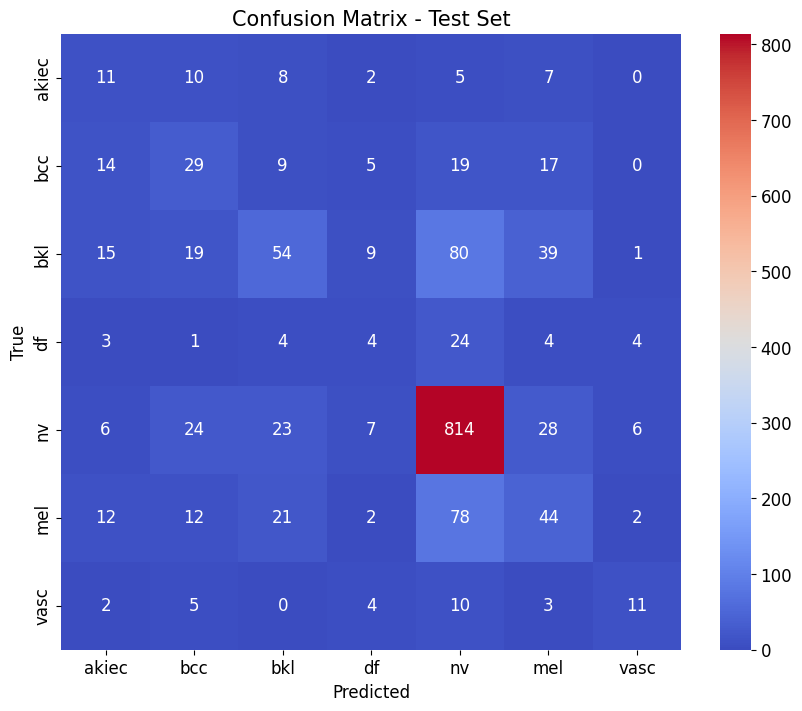

In [199]:
cm = confusion_matrix(y_test, y_pred)



plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [201]:
class_correct = np.zeros(7)
class_total = np.zeros(7)

for t, p in zip(y_test, y_pred):
    class_total[t] += 1
    if t == p:
        class_correct[t] += 1

class_acc = class_correct / class_total

for i in range(7):
    print(class_names[i], ":", round(class_acc[i], 3))

akiec : 0.256
bcc : 0.312
bkl : 0.249
df : 0.091
nv : 0.896
mel : 0.257
vasc : 0.314


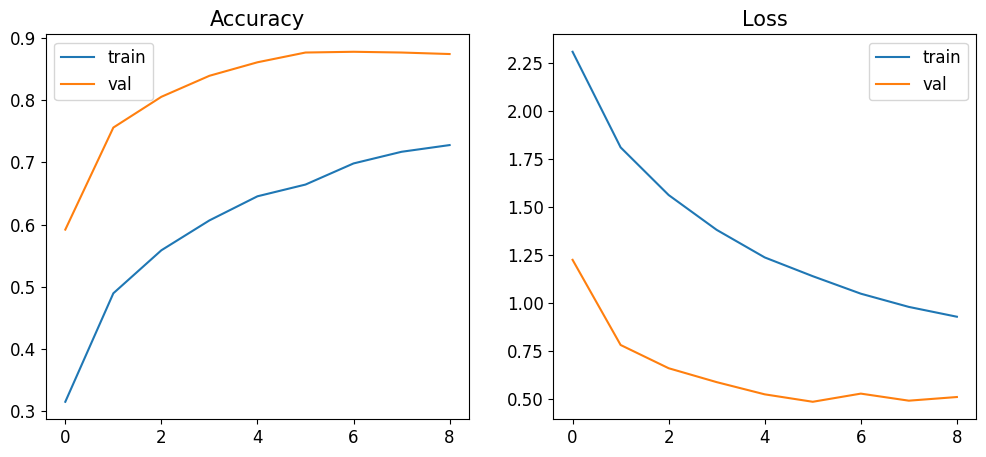

In [202]:
import matplotlib.pyplot as plt

history = history_finetune.history

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["accuracy"], label="train")
plt.plot(history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.show()

In [203]:
model.save("skin_cancer_model.h5")